# 04 — Phase 2: What *kind* of hospital readmits more?
**ReadmitScope US**

Phase 1 showed readmissions are systemic and volume-linked. Here we enrich the HRRP
data with **CMS Hospital General Information** (ownership, hospital type, overall star
rating) to ask: do *for-profit* hospitals and *lower-rated* hospitals readmit more —
even after CMS's risk adjustment?

Join key: `Facility ID` (CCN). Match rate ≈ 99.7% of reported HRRP hospitals.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid")
ORANGE, DARK = "#FF8000", "#0D0D0D"
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10})
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "hrrp_enriched.csv", dtype={"facility_id": str})
print(len(df), "reported measures;", df["facility_id"].nunique(), "hospitals")

11720 reported measures; 2833 hospitals


## 1. Ownership
CMS lists 12 ownership values; grouped into Non-profit, For-profit, Government, Federal/Military.

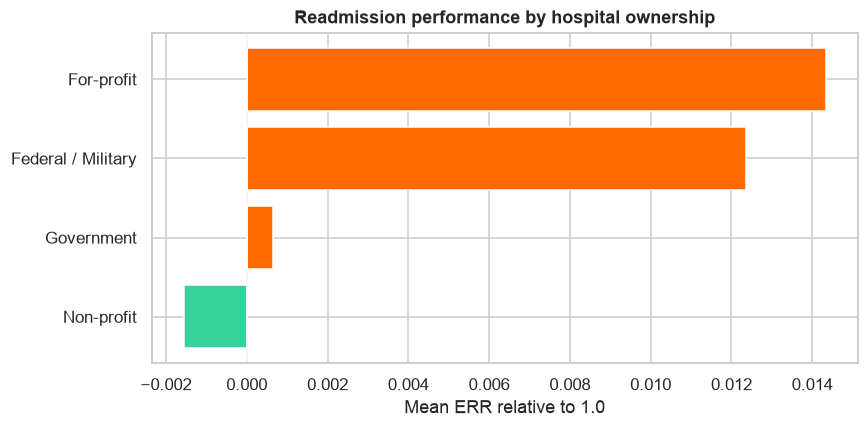

,mean_err,pct_worse,n
ownership,,,
For-profit,1.014,54.123,603
Federal / Military,1.012,58.824,18
Government,1.001,49.574,374
Non-profit,0.998,46.190,1830


In [2]:
own = (df.dropna(subset=['ownership']).groupby('ownership')
         .agg(mean_err=('err','mean'), pct_worse=('err',lambda s:(s>1).mean()*100),
              n=('facility_id','nunique')).sort_values('mean_err', ascending=False))
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(own.index, own['mean_err']-1, color=['#FF6B00' if v>1 else '#34D399' for v in own['mean_err']])
ax.axvline(0, color='#fff', lw=1); ax.set_xlabel('Mean ERR relative to 1.0')
ax.set_title('Readmission performance by hospital ownership'); ax.invert_yaxis()
plt.tight_layout(); plt.show()
own.round(3)

In [3]:
groups = [g['err'].values for _,g in df.dropna(subset=['ownership']).groupby('ownership')]
h, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis across ownership groups: H={h:.1f}, p={p:.2e}")
fp, nfp = df[df['ownership']=='For-profit']['err'], df[df['ownership']=='Non-profit']['err']
u, p2 = stats.mannwhitneyu(fp, nfp, alternative='greater')
print(f"For-profit vs Non-profit (one-sided): p={p2:.2e}")
print(f"  median ERR  for-profit={fp.median():.4f}  non-profit={nfp.median():.4f}")

Kruskal-Wallis across ownership groups: H=77.0, p=1.37e-16


For-profit vs Non-profit (one-sided): p=5.02e-18
  median ERR  for-profit=1.0069  non-profit=0.9944


**Read:** ownership groups differ significantly (Kruskal–Wallis p ≪ 0.001). **For-profit** hospitals readmit significantly more than **non-profit** (Mann–Whitney p ≪ 0.001), even though ERR is risk-adjusted.

## 2. Overall star rating
CMS's 1–5 star summary quality rating. Is it associated with readmissions?

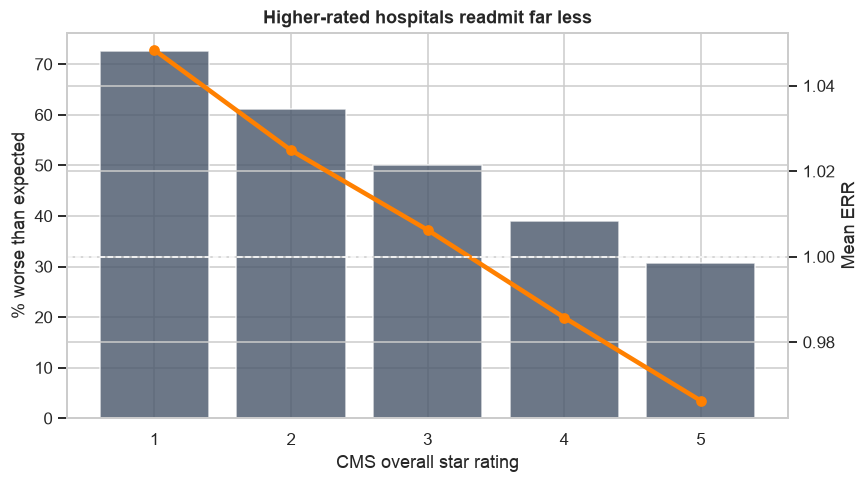

,mean_err,pct_worse,n
star_rating,,,
1.0,1.048,72.632,170
2.0,1.025,61.047,568
3.0,1.006,50.014,842
4.0,0.986,38.920,761
5.0,0.966,30.691,287


In [4]:
rat = (df.dropna(subset=['star_rating']).groupby('star_rating')
         .agg(mean_err=('err','mean'), pct_worse=('err',lambda s:(s>1).mean()*100),
              n=('facility_id','nunique')))
fig, ax1 = plt.subplots(figsize=(8,4.5))
ax1.bar(rat.index, rat['pct_worse'], color='#475569', alpha=0.8, label='% worse than expected')
ax1.set_ylabel('% worse than expected'); ax1.set_xlabel('CMS overall star rating')
ax2 = ax1.twinx()
ax2.plot(rat.index, rat['mean_err'], marker='o', color=ORANGE, lw=3, label='Mean ERR')
ax2.axhline(1.0, color='#fff', ls='--', lw=1); ax2.set_ylabel('Mean ERR')
ax1.set_title('Higher-rated hospitals readmit far less')
plt.tight_layout(); plt.show()
rat.round(3)

In [5]:
sub = df.dropna(subset=['star_rating'])
rho, p = stats.spearmanr(sub['star_rating'], sub['err'])
print(f"Spearman (star rating vs ERR): rho={rho:.3f}, p={p:.2e}  (n={len(sub):,})")

Spearman (star rating vs ERR): rho=-0.273, p=1.92e-195  (n=11,458)


**Read:** a strong, clean **dose–response**: mean ERR falls from **1.048 (★1)** to
**0.966 (★5)**, and the share worse-than-expected drops from **73% to 31%**. Spearman
ρ ≈ −0.27 (p ≪ 0.001). The overall star rating is a meaningful proxy for readmission risk.

## 3. Why hospital *type* doesn't vary here

In [6]:
print(df.dropna(subset=['hospital_type']).groupby('hospital_type')['facility_id'].nunique())
print("\n=> Critical Access & specialty hospitals are largely EXEMT from HRRP,")
print("   so reported HRRP measures are almost entirely Acute Care Hospitals.")

hospital_type
Acute Care Hospitals    2825
Name: facility_id, dtype: int64

=> Critical Access & specialty hospitals are largely EXEMT from HRRP,
   so reported HRRP measures are almost entirely Acute Care Hospitals.


## Phase 2 findings
1. **For-profit hospitals readmit more** than non-profit/government — significant after
   risk adjustment (Kruskal–Wallis p ≪ 0.001; for-profit median ERR 1.007 vs non-profit 0.994).
2. **Star rating tracks readmissions strongly** — ★1 hospitals are worse-than-expected
   73% of the time vs 31% for ★5; Spearman ρ ≈ −0.27 (p ≪ 0.001).
3. **Hospital type is not informative** in this data because HRRP applies to acute-care
   hospitals; critical-access and specialty hospitals are largely exempt.

These attribute-level signals point to *who* to prioritise for readmission-reduction
support: lower-rated and for-profit acute-care hospitals.